In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = np.array(Image.open('image.jpg')).astype(np.float32)

R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

img = 0.299 * R + 0.587 * G + 0.114 * B
img = img[::5, ::5]

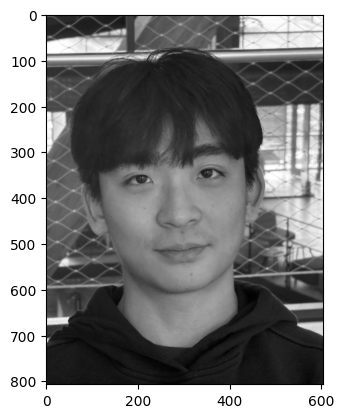

In [3]:
plt.imshow(img.T, cmap='gray')
plt.show()

In [4]:
def apply_filter(img, z):
  k = z.shape[0] // 2

  img_pad = np.pad(img, k, mode='reflect')
  new = np.zeros_like(img)

  for i in range(img.shape[0]):
    for j in range(img.shape[1]):
      new[i,j] += np.sum(img_pad[i:i+2*k+1, j:j+2*k+1] * z[::-1,::-1])
  return new

In [17]:
x_sobel = np.array([
[-3, -2, -1, 0, 1, 2, 3],
[-4, -3, -2, 0, 2, 3, 4],
[-5, -4, -3, 0, 3, 4, 5],
[-6, -5, -4, 0, 4, 5, 6],
[-5, -4, -3, 0, 3, 4, 5],
[-4, -3, -2, 0, 2, 3, 4],
[-3, -2, -1, 0, 1, 2, 3]])

y_sobel = np.array([
[-3, -4, -5, -6, -5, -4, -3],
[-2, -3, -4, -5, -4, -3, -2],
[-1, -2, -3, -4, -3, -2, -1],
[ 0,  0,  0,  0,  0,  0,  0],
[ 1,  2,  3,  4,  3,  2,  1],
[ 2,  3,  4,  5,  4,  3,  2],
[ 3,  4,  5,  6,  5,  4,  3]])

grad_x = apply_filter(img, x_sobel)
grad_y = apply_filter(img, y_sobel)

In [40]:
grad = ((grad_x**2)+(grad_y**2))**0.5
THRES = 1500
edges = np.where(grad > THRES, 1, 0)

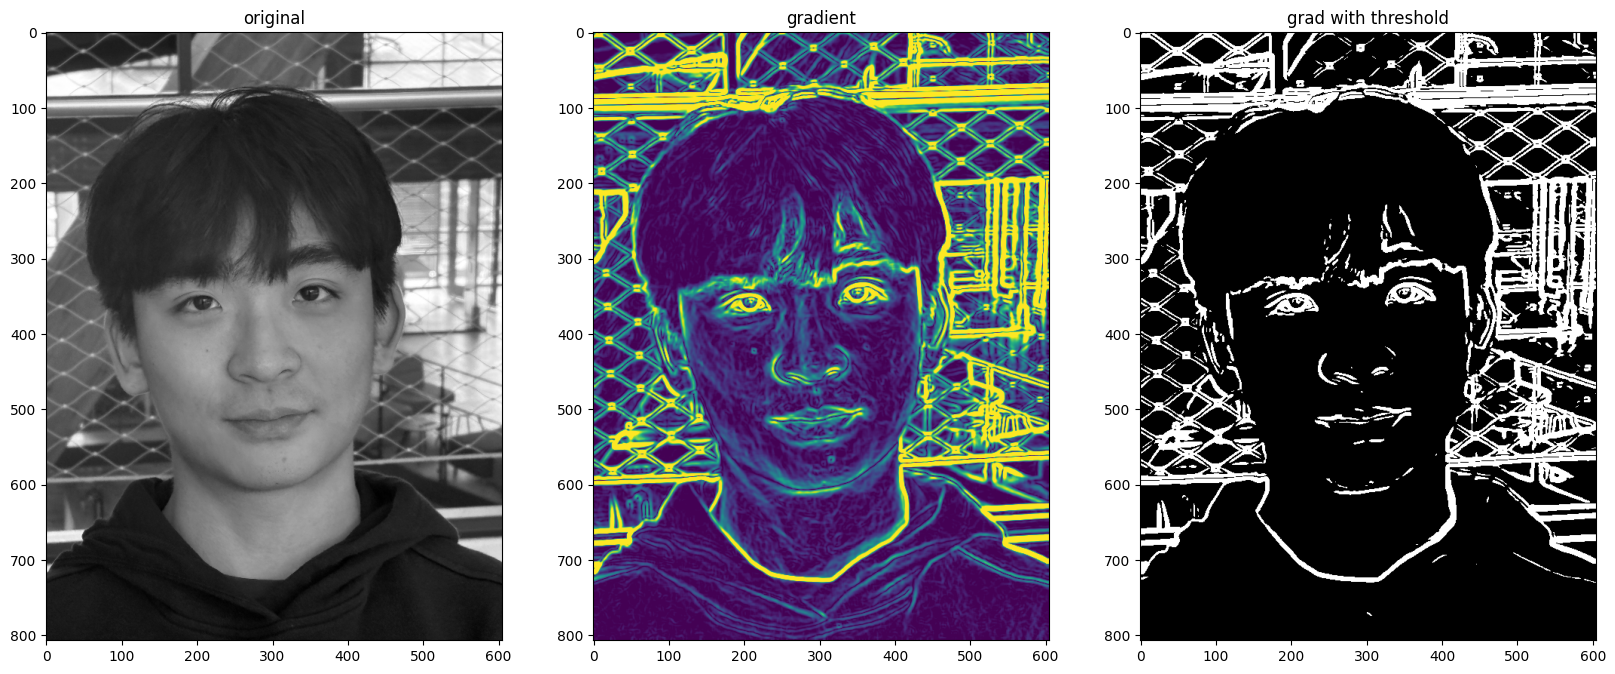

In [43]:
plt.figure(figsize=(20,10))
plt.subplot(1,3,1)
plt.title('original')
plt.imshow(img.T, cmap='gray')
plt.subplot(1,3,2)
plt.title('gradient')
vmin = np.percentile(grad, 10)
vmax = np.percentile(grad, 90)
plt.imshow(grad.T, vmin = vmin, vmax = vmax)
plt.subplot(1,3,3)
plt.title('grad with threshold')
plt.imshow(edges.T, cmap='gray')
plt.show()